In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#   kernelspec:
#     display_name: Python 3
#     language: python
#     name: python3
# ---

# $H(q,p) = h(q) + D_{KL}(q\|p)$ — 숫자로 확인하고 눈으로 보기

교차엔트로피는 **두 조각**으로 정확히 쪼개진다.

$$H(q, p) = \underbrace{h(q)}_{\text{teacher 분포의 엔트로피}} + \underbrace{D_{KL}(q \,\|\, p)}_{\text{student가 teacher와 다른 정도}}$$

이 노트북에서 할 일:

1. 항등식을 **한 줄 로그 트릭**으로 유도하고 코드로 확인
2. 원본 노트북의 **5가지 case**에 대해 $H = h + KL$을 수치로 검증
3. $D_{KL} \ge 0$을 $\log x \le x-1$ 접선 부등식으로 그림으로 확인
4. **teacher 온도 $\tau_t$ 스윕** — loss가 줄어들 때 그 감소분이 $h(q)$에서 나오는지 $KL$에서 나오는지 눈으로 구분

의존성: `torch`, `plotly`, `kaleido`.

In [2]:
import math

import torch
import torch.nn.functional as F
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


torch.manual_seed(0)
torch.set_printoptions(precision=3, sci_mode=False)
print("ready")

ready


## 1. 세 함수 정의

셋 다 "$q_i$를 가중치로 하는 평균"이라는 점이 같다. 안에 든 것만 다르다.

$$h(q) = -\sum_i q_i \log q_i, \quad
  H(q,p) = -\sum_i q_i \log p_i, \quad
  D_{KL}(q\|p) = \sum_i q_i (\log q_i - \log p_i)$$

In [3]:
def entropy(p):
    return -(p * p.clamp_min(1e-12).log()).sum(-1)


def cross_entropy(q, p):
    return -(q * p.clamp_min(1e-12).log()).sum(-1)


def kl(q, p):
    return (q * (q.clamp_min(1e-12).log() - p.clamp_min(1e-12).log())).sum(-1)


def z(v):
    """-0.000 같은 표시를 0.000으로 정리."""
    return 0.0 if abs(v) < 5e-7 else v


K = 8
one_hot = F.one_hot(torch.tensor(3), K).float()
uniform = torch.full((K,), 1 / K)
peaked = F.softmax(torch.tensor([4., 1., 0., 0., 0., 0., 0., 0.]), -1)

print("one_hot", one_hot.numpy().round(3))
print("peaked ", peaked.numpy().round(3))
print("uniform", uniform.numpy().round(3))
print(f"log K = log {K} = {math.log(K):.4f}")

one_hot [0. 0. 0. 1. 0. 0. 0. 0.]
peaked  [0.862 0.043 0.016 0.016 0.016 0.016 0.016 0.016]
uniform [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
log K = log 8 = 2.0794


## 2. 유도 — 로그 한 줄 트릭

항등식의 전부는 이 한 줄이다. $\log p_i$를 억지로 $\log q_i$가 보이게 쪼갠다.

$$\log p_i = \log q_i - (\log q_i - \log p_i)$$

대입하면:

$$H(q,p) = -\sum_i q_i \log p_i
  = \underbrace{-\sum_i q_i \log q_i}_{h(q)}
  + \underbrace{\sum_i q_i (\log q_i - \log p_i)}_{D_{KL}(q\|p)}$$

코드로 "쪼개기 전"과 "쪼갠 후"의 **항별 배열**이 똑같은지 확인해 보자.

In [4]:
q, p = peaked, uniform

lhs_terms = -(q * p.log())                       # -q_i log p_i
rhs_terms = -(q * q.log()) + q * (q.log() - p.log())   # h 항 + KL 항

print("i   -q log p     h항 + KL항")
for i in range(K):
    print(f"{i}   {lhs_terms[i]: .6f}    {rhs_terms[i]: .6f}")
print(f"\nmax |차이| = {(lhs_terms - rhs_terms).abs().max():.3e}   ← 항별로 완전히 동일")

i   -q log p     h항 + KL항
0    1.793115     1.793115
1    0.089274     0.089274
2    0.032842     0.032842
3    0.032842     0.032842
4    0.032842     0.032842
5    0.032842     0.032842
6    0.032842     0.032842
7    0.032842     0.032842

max |차이| = 0.000e+00   ← 항별로 완전히 동일


합계뿐 아니라 **$i$마다 하나하나** 같다. 항등식은 근사나 부등식이 아니라 대수적으로 완전한 등식이다.

## 3. 5가지 case로 수치 검증

원본 노트북 2절과 같은 case들이다. `H`, `h`, `KL`, `h+KL`을 나란히 찍는다.

In [5]:
cases = [
    ("q=peaked,  p=peaked  (완벽히 맞춤)", peaked, peaked),
    ("q=peaked,  p=uniform (student가 아무것도 못함)", peaked, uniform),
    ("q=one_hot, p=peaked  (지도학습 상황)", one_hot, peaked),
    ("q=uniform, p=uniform (둘 다 균등)", uniform, uniform),
    ("q=one_hot, p=one_hot (둘 다 같은 원-핫)", one_hot, one_hot),
]

rows = []
print(f"{'case':48s} {'H(q,p)':>8s} {'h(q)':>7s} {'KL':>7s} {'h+KL':>7s} {'|차이|':>9s}")
for name, qq, pp in cases:
    H, h, D = cross_entropy(qq, pp).item(), entropy(qq).item(), kl(qq, pp).item()
    rows.append((name, H, h, D))
    print(f"{name:48s} {z(H):8.3f} {z(h):7.3f} {z(D):7.3f} {z(h + D):7.3f} {abs(H - h - D):9.2e}")

case                                               H(q,p)    h(q)      KL    h+KL      |차이|
q=peaked,  p=peaked  (완벽히 맞춤)                       0.656   0.656   0.000   0.656  0.00e+00
q=peaked,  p=uniform (student가 아무것도 못함)             2.079   0.656   1.423   2.079  1.19e-07
q=one_hot, p=peaked  (지도학습 상황)                      4.148   0.000   4.148   4.148  0.00e+00
q=uniform, p=uniform (둘 다 균등)                       2.079   2.079   0.000   2.079  0.00e+00
q=one_hot, p=one_hot (둘 다 같은 원-핫)                   0.000   0.000   0.000   0.000  0.00e+00


### 표 읽는 법 — 특히 마지막 두 줄

| case | $H$ | $h(q)$ | $KL$ | 해석 |
|---|---|---|---|---|
| peaked / peaked | 0.656 | **0.656** | 0 | student 완벽. loss가 남은 건 전부 teacher의 엔트로피 |
| peaked / uniform | 2.079 | 0.656 | **1.423** | loss 대부분이 KL — student가 못 따라감 |
| one_hot / peaked | 4.148 | 0 | **4.148** | 지도학습: $h(q)=0$이라 loss = KL 그 자체 |
| uniform / uniform | 2.079 | **2.079** | 0 | **균등 붕괴.** KL=0인데 loss는 $\log 8$에 갇힘 |
| one_hot / one_hot | **0** | 0 | 0 | **원-핫 붕괴.** loss=0, 완벽한 점수 |

두 붕괴 상태의 차이가 분해에서 그대로 드러난다:
둘 다 $KL=0$(student가 teacher를 완벽히 따라감)인데, **$h(q)$ 값만 다르다.**
그리고 loss는 오직 $h(q)$ 때문에 달라진다.

지도학습에서는 $q$가 고정 레이블이라 $h(q)$가 상수 → $\arg\min H = \arg\min KL$.
**DINO에서는 teacher가 student의 EMA라 $q$도 움직인다** → $h(q)$를 깎아서 loss를 낮추는 길이 열린다.

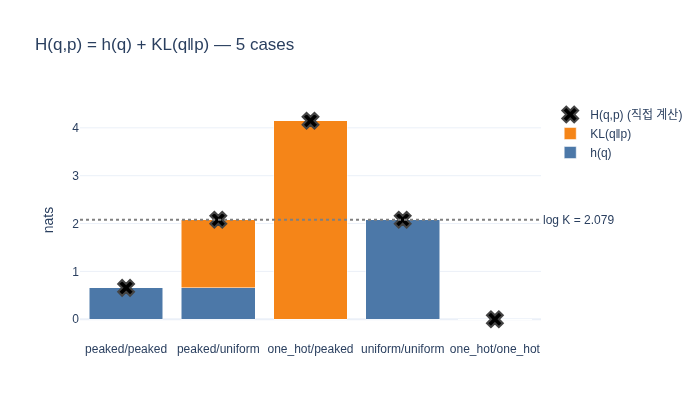

bar chart ready (검은 x = 직접 계산한 H, 막대 총합과 일치)


In [6]:
# 같은 결과를 막대그래프로 — H를 h(q)와 KL로 쌓아 올린다
labels = ["peaked/peaked", "peaked/uniform", "one_hot/peaked", "uniform/uniform", "one_hot/one_hot"]
fig = go.Figure()
fig.add_bar(x=labels, y=[r[2] for r in rows], name="h(q)", marker_color="#4C78A8")
fig.add_bar(x=labels, y=[r[3] for r in rows], name="KL(q‖p)", marker_color="#F58518")
fig.add_scatter(x=labels, y=[r[1] for r in rows], name="H(q,p) (직접 계산)",
                mode="markers", marker=dict(symbol="x", size=14, color="black", line_width=2))
fig.add_hline(y=math.log(K), line_dash="dot", line_color="gray",
              annotation_text="log K = 2.079", annotation_position="right")
fig.update_layout(barmode="stack", title="H(q,p) = h(q) + KL(q‖p) — 5 cases",
                  yaxis_title="nats", height=420, template="plotly_white")
_show(fig)
print("bar chart ready (검은 x = 직접 계산한 H, 막대 총합과 일치)")

## 4. $D_{KL} \ge 0$ — 접선 부등식 $\log x \le x - 1$

$f(x) = x - 1 - \log x$를 미분하면 $f'(x) = 1 - 1/x$, $f''(x) = 1/x^2 > 0$.
$x=1$에서 최솟값 $f(1) = 0$이므로 모든 $x>0$에서 $\log x \le x-1$ (등호는 $x=1$).

이걸 $x = p_i/q_i$에 적용하면:

$$-D_{KL}(q\|p) = \sum_i q_i \log\frac{p_i}{q_i} \le \sum_i q_i\left(\frac{p_i}{q_i} - 1\right) = \sum_i p_i - \sum_i q_i = 0$$

즉 $D_{KL} \ge 0$, 등호는 $p = q$일 때만. 따라서 $H(q,p) \ge h(q)$ — **loss는 $h(q)$ 아래로 못 내려간다.**

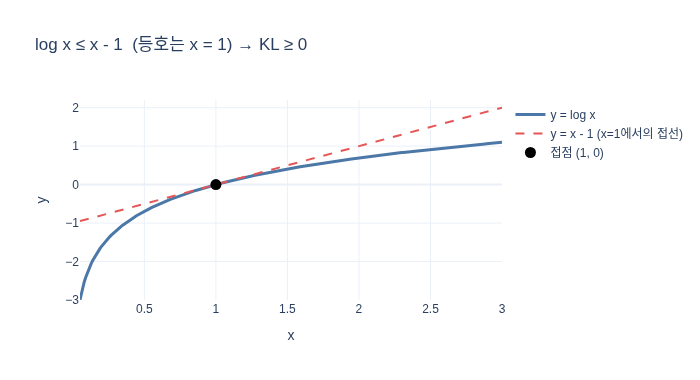

랜덤 2000쌍 KL:  min=0.1261  mean=2.3506  max=8.0067  (음수 개수=0)
KL(q, q) = 0.000e+00   ← p=q이면 정확히 0


In [7]:
xs = torch.linspace(0.05, 3.0, 300)
fig = go.Figure()
fig.add_scatter(x=xs, y=xs.log(), name="y = log x", line=dict(color="#4C78A8", width=3))
fig.add_scatter(x=xs, y=xs - 1, name="y = x - 1 (x=1에서의 접선)", line=dict(color="#E45756", width=2, dash="dash"))
fig.add_scatter(x=[1], y=[0], name="접점 (1, 0)", mode="markers", marker=dict(size=11, color="black"))
fig.update_layout(title="log x ≤ x - 1  (등호는 x = 1) → KL ≥ 0",
                  xaxis_title="x", yaxis_title="y", height=380, template="plotly_white",
                  yaxis_range=[-3, 2.2])
_show(fig)

# 수치 확인: 랜덤 분포 쌍 2000개의 KL 최솟값
qs = torch.softmax(torch.randn(2000, K) * 2, -1)
ps = torch.softmax(torch.randn(2000, K) * 2, -1)
d = kl(qs, ps)
print(f"랜덤 2000쌍 KL:  min={d.min():.4f}  mean={d.mean():.4f}  max={d.max():.4f}  (음수 개수={(d < 0).sum().item()})")
print(f"KL(q, q) = {kl(qs, qs).abs().max():.3e}   ← p=q이면 정확히 0")

## 5. teacher 온도 $\tau_t$ 스윕 — loss 감소분은 어디서 오나

여기가 핵심이다. DINO는 teacher 로짓을 낮은 온도로 나눠 **sharpening** 한다.

$$q_i(\tau_t) = \frac{\exp(z_i / \tau_t)}{\sum_j \exp(z_j / \tau_t)}$$

$\tau_t$가 작아질수록 $q$는 뾰족해지고 $h(q) \downarrow$.
student $p$는 **고정**해 놓고(온도 $\tau_s = 0.1$) $\tau_t$만 훑으면서 $H$, $h(q)$, $KL$이 각각 어떻게 움직이는지 본다.

> 이 실험이 답하는 질문: **"loss가 줄었다. 그런데 student가 좋아진 건가($KL\downarrow$),
> 아니면 teacher가 뾰족해진 것뿐인가($h\downarrow$)?"**

In [8]:
teacher_logits = torch.tensor([2.0, 1.5, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])
# teacher와 순서는 같지만 훨씬 덜 확신하는, 고정된 student
student_logits = torch.tensor([0.35, 0.30, 0.20, 0.10, 0.0, 0.0, 0.0, 0.0])
p_fixed = F.softmax(student_logits / 0.1, -1)                              # student temp = 0.1, 고정
print("q(τ_t=1.0) =", F.softmax(teacher_logits, -1).numpy().round(3))
print("p (고정)    =", p_fixed.numpy().round(3))

taus = torch.logspace(math.log10(0.02), math.log10(3.0), 60)
H_list, h_list, KL_list = [], [], []
for t in taus:
    q_t = F.softmax(teacher_logits / t, -1)
    H_list.append(cross_entropy(q_t, p_fixed).item())
    h_list.append(entropy(q_t).item())
    KL_list.append(kl(q_t, p_fixed).item())

print(f"{'tau_t':>7s} {'H':>8s} {'h(q)':>8s} {'KL':>8s}   {'h가 차지하는 비율':>10s}")
for t, H, h, D in list(zip(taus, H_list, h_list, KL_list))[::12]:
    print(f"{t:7.3f} {H:8.3f} {h:8.3f} {D:8.3f}   {h / H * 100:9.1f}%")
print(f"\n스윕 전체: H {H_list[-1]:.3f} → {H_list[0]:.3f},  "
      f"h(q) {h_list[-1]:.3f} → {h_list[0]:.3f},  KL {KL_list[-1]:.3f} → {KL_list[0]:.3f}")

q(τ_t=1.0) = [0.365 0.221 0.134 0.081 0.049 0.049 0.049 0.049]
p (고정)    = [0.492 0.298 0.11  0.04  0.015 0.015 0.015 0.015]
  tau_t        H     h(q)       KL   h가 차지하는 비율
  0.020    0.709    0.000    0.709         0.0%
  0.055    0.709    0.001    0.708         0.2%
  0.154    0.730    0.170    0.560        23.3%
  0.425    1.048    0.971    0.077        92.7%
  1.179    2.077    1.854    0.224        89.2%

스윕 전체: H 2.663 → 0.709,  h(q) 2.046 → 0.000,  KL 0.616 → 0.709


### 시각화 — 3개 패널

- **왼쪽**: $H$를 $h(q)$와 $KL$로 **쌓아 올린** stacked area. 총 높이가 loss, 아래 파란 층이 "teacher가 뾰족해서 줄어든 몫".
- **가운데**: 같은 데이터를 line으로. $\tau_t \downarrow$ 방향으로 세 곡선이 어떻게 움직이는지.
- **오른쪽**: 몇 개 $\tau_t$에서의 실제 $q$ 분포 모양.

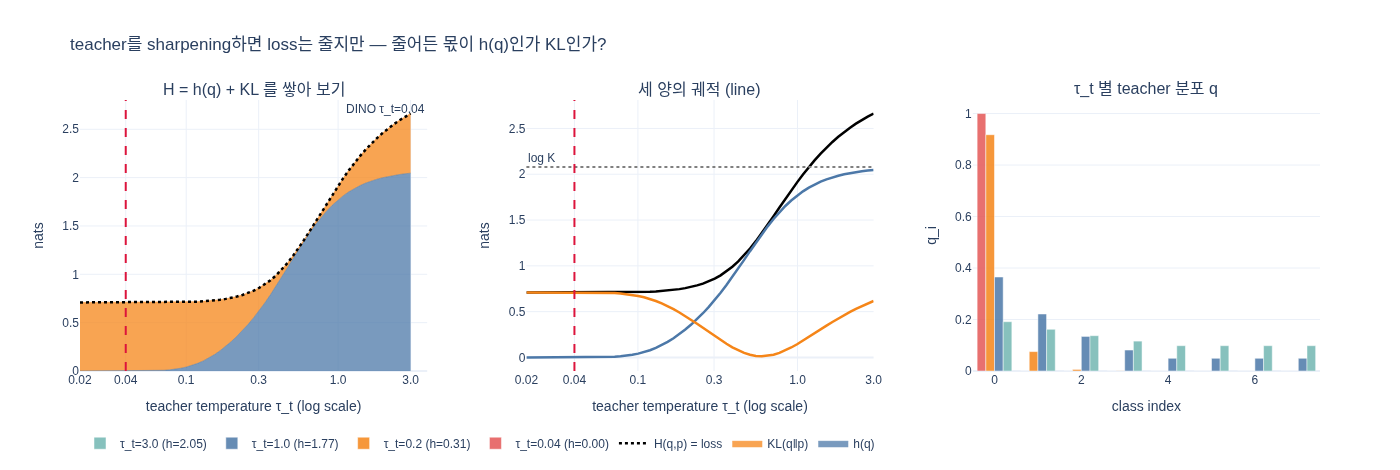

saved expy.png


In [9]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("H = h(q) + KL 를 쌓아 보기", "세 양의 궤적 (line)", "τ_t 별 teacher 분포 q"),
    horizontal_spacing=0.08,
)

x = taus.tolist()

# --- (1) stacked area: 아래 h(q), 위 KL ---
fig.add_scatter(x=x, y=h_list, name="h(q)", mode="lines", line=dict(width=0.5, color="#4C78A8"),
                stackgroup="one", fillcolor="rgba(76,120,168,0.75)", row=1, col=1)
fig.add_scatter(x=x, y=KL_list, name="KL(q‖p)", mode="lines", line=dict(width=0.5, color="#F58518"),
                stackgroup="one", fillcolor="rgba(245,133,24,0.75)", row=1, col=1)
fig.add_scatter(x=x, y=H_list, name="H(q,p) = loss", mode="lines",
                line=dict(color="black", width=2.5, dash="dot"), row=1, col=1)
fig.add_vline(x=0.04, line_dash="dash", line_color="crimson", row=1, col=1,
              annotation_text="DINO τ_t=0.04", annotation_position="top right")

# --- (2) line plot ---
for name, ys, c in [("H(q,p)", H_list, "black"), ("h(q)", h_list, "#4C78A8"), ("KL(q‖p)", KL_list, "#F58518")]:
    fig.add_scatter(x=x, y=ys, name=name + " ", mode="lines", line=dict(color=c, width=2.5),
                    showlegend=False, row=1, col=2)
fig.add_hline(y=math.log(K), line_dash="dot", line_color="gray", row=1, col=2,
              annotation_text="log K", annotation_position="top left")
fig.add_vline(x=0.04, line_dash="dash", line_color="crimson", row=1, col=2)

# --- (3) 몇 개 tau에서의 q 모양 ---
for t, c in [(0.04, "#E45756"), (0.2, "#F58518"), (1.0, "#4C78A8"), (3.0, "#72B7B2")]:
    q_t = F.softmax(teacher_logits / t, -1)
    fig.add_bar(x=list(range(K)), y=q_t.tolist(), name=f"τ_t={t} (h={entropy(q_t):.2f})",
                marker_color=c, opacity=0.85, row=1, col=3)

TICKS = [0.02, 0.04, 0.1, 0.3, 1.0, 3.0]
for c in (1, 2):
    fig.update_xaxes(type="log", title_text="teacher temperature τ_t (log scale)",
                     tickmode="array", tickvals=TICKS, ticktext=[str(t) for t in TICKS],
                     row=1, col=c)
fig.update_xaxes(title_text="class index", row=1, col=3)
fig.update_yaxes(title_text="nats", row=1, col=1)
fig.update_yaxes(title_text="nats", row=1, col=2)
fig.update_yaxes(title_text="q_i", row=1, col=3)
fig.update_layout(height=470, width=1400, template="plotly_white", barmode="group",
                  title_text="teacher를 sharpening하면 loss는 줄지만 — 줄어든 몫이 h(q)인가 KL인가?",
                  legend=dict(orientation="h", yanchor="bottom", y=-0.32))
_show(fig)

fig.write_image("expy.png", scale=2)
print("saved expy.png")

### 그림 읽는 법 — 이게 핵심이다

$\tau_t$를 오른쪽(평평, $\tau_t=3$)에서 왼쪽(뾰족, $\tau_t=0.02$)으로 훑으면
**loss $H$가 $2.66 \to 0.71$로 떨어진다.** 약 1.95 nats 감소.

그 감소분이 어디서 나왔는지 층을 보면:

| | $\tau_t = 3$ | $\tau_t = 0.02$ | 변화 |
|---|---|---|---|
| 파란 층 $h(q)$ | 2.046 | 0.000 | **−2.05** ← 감소분 전부 |
| 주황 층 $KL$ | 0.616 | 0.709 | **+0.09** (오히려 나빠짐!) |
| $H$ = loss | 2.663 | 0.709 | −1.95 |

**student는 단 한 번도 업데이트되지 않았다.** $p$는 처음부터 끝까지 같은 벡터다.
그런데 loss는 3분의 1 이하로 줄었다. 줄어든 건 전부 $h(q)$ — teacher 분포를 뾰족하게 만든 것뿐이다.
심지어 $KL$은 **살짝 늘었다**: student와 teacher의 불일치는 오히려 커졌는데 loss는 내려갔다.

이게 (b) 경로, 즉 **붕괴 통로**다. loss 숫자만 보면 "학습이 잘 되고 있다"고 착각한다.
표로 다시 확인해 보자.

In [10]:
# student는 그대로 두고 teacher만 뾰족하게 → loss가 0으로
for t in [3.0, 1.0, 0.3, 0.1, 0.04, 0.02]:
    q_t = F.softmax(teacher_logits / t, -1)
    print(f"τ_t={t:5.2f}  H={cross_entropy(q_t, p_fixed):6.3f}  "
          f"h(q)={entropy(q_t):6.3f}  KL={kl(q_t, p_fixed):6.3f}   "
          f"(student p는 한 번도 안 바뀜)")

τ_t= 3.00  H= 2.663  h(q)= 2.046  KL= 0.616   (student p는 한 번도 안 바뀜)
τ_t= 1.00  H= 1.917  h(q)= 1.770  KL= 0.147   (student p는 한 번도 안 바뀜)
τ_t= 0.30  H= 0.857  h(q)= 0.618  KL= 0.239   (student p는 한 번도 안 바뀜)
τ_t= 0.10  H= 0.713  h(q)= 0.041  KL= 0.672   (student p는 한 번도 안 바뀜)
τ_t= 0.04  H= 0.709  h(q)= 0.000  KL= 0.709   (student p는 한 번도 안 바뀜)
τ_t= 0.02  H= 0.709  h(q)= 0.000  KL= 0.709   (student p는 한 번도 안 바뀜)


## 6. 대조 실험 — "진짜 학습"은 어떻게 다른가

이번엔 반대로 $\tau_t$를 **고정**하고(여기선 $h(q)$ 층이 눈에 보이도록 $\tau_t = 0.3$) student만 teacher 쪽으로 조금씩 옮긴다.

student 로짓을 $z_s^{(\alpha)} = (1-\alpha)\,z_s + \alpha\, z^{\star}$로 보간한다.
여기서 목표 $z^{\star} = z_t \cdot (\tau_s/\tau_t)$ — student 온도 $\tau_s=0.1$로 나눴을 때 정확히 $p = q$가 되는 로짓이다.
따라서 $\alpha=0$은 원래 student, $\alpha=1$은 **teacher를 완벽히 재현한 student**.

In [11]:
alphas = torch.linspace(0, 1, 41)
TAU_T_FIXED, TAU_S = 0.3, 0.1
q_fixed = F.softmax(teacher_logits / TAU_T_FIXED, -1)   # τ_t 고정 → h(q)도 고정
h_fixed = entropy(q_fixed).item()
target_logits = teacher_logits * (TAU_S / TAU_T_FIXED)  # softmax(target/τ_s) == q_fixed

H2, KL2 = [], []
for a in alphas:
    zl = (1 - a) * student_logits + a * target_logits
    p_a = F.softmax(zl / TAU_S, -1)
    H2.append(cross_entropy(q_fixed, p_a).item())
    KL2.append(kl(q_fixed, p_a).item())

print(f"h(q) 고정값 = {h_fixed:.4f}  (τ_t={TAU_T_FIXED})")
for a, H, D in list(zip(alphas, H2, KL2))[::10]:
    print(f"α={a:4.2f}  H={z(H):6.3f}  h(q)={h_fixed:6.3f}  KL={z(D):6.3f}")
print(f"\nH가 {H2[0]:.3f} → {H2[-1]:.3f}로 줄었고, 그 감소분 {H2[0] - H2[-1]:.3f}는 전부 KL에서 나왔다"
      f"  (h(q)는 {h_fixed:.3f}로 못 박혀 있다)")
print(f"그리고 H는 h(q)={h_fixed:.3f}에서 정확히 멈춘다 — KL≥0 이므로 H는 h(q) 아래로 못 내려간다.")

h(q) 고정값 = 0.6177  (τ_t=0.3)
α=0.00  H= 0.857  h(q)= 0.618  KL= 0.239
α=0.25  H= 0.739  h(q)= 0.618  KL= 0.121
α=0.50  H= 0.666  h(q)= 0.618  KL= 0.048
α=0.75  H= 0.629  h(q)= 0.618  KL= 0.011
α=1.00  H= 0.618  h(q)= 0.618  KL= 0.000

H가 0.857 → 0.618로 줄었고, 그 감소분 0.239는 전부 KL에서 나왔다  (h(q)는 0.618로 못 박혀 있다)
그리고 H는 h(q)=0.618에서 정확히 멈춘다 — KL≥0 이므로 H는 h(q) 아래로 못 내려간다.


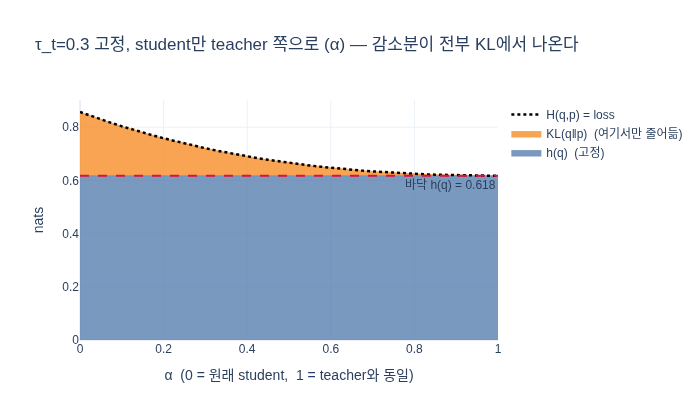

대조 실험 그림 준비 완료 — 파란 h(q) 층은 두께가 변하지 않는다


In [12]:
fig = go.Figure()
fig.add_scatter(x=alphas.tolist(), y=[h_fixed] * len(alphas), name="h(q)  (고정)",
                mode="lines", line=dict(width=0.5, color="#4C78A8"),
                stackgroup="one", fillcolor="rgba(76,120,168,0.75)")
fig.add_scatter(x=alphas.tolist(), y=KL2, name="KL(q‖p)  (여기서만 줄어듦)",
                mode="lines", line=dict(width=0.5, color="#F58518"),
                stackgroup="one", fillcolor="rgba(245,133,24,0.75)")
fig.add_scatter(x=alphas.tolist(), y=H2, name="H(q,p) = loss",
                mode="lines", line=dict(color="black", width=2.5, dash="dot"))
fig.update_layout(
    title=f"τ_t={TAU_T_FIXED} 고정, student만 teacher 쪽으로 (α) — 감소분이 전부 KL에서 나온다",
    xaxis_title="α  (0 = 원래 student,  1 = teacher와 동일)", yaxis_title="nats",
    height=420, template="plotly_white",
)
fig.add_hline(y=h_fixed, line_dash="dash", line_color="crimson",
              annotation_text=f"바닥 h(q) = {h_fixed:.3f}", annotation_position="bottom right")
_show(fig)
print("대조 실험 그림 준비 완료 — 파란 h(q) 층은 두께가 변하지 않는다")

## 7. 정리

$$H(q, p) = h(q) + D_{KL}(q\|p), \qquad D_{KL} \ge 0 \;\Rightarrow\; H \ge h(q)$$

**loss가 줄어드는 두 경로 — 5절과 6절은 같은 loss 감소를 두 가지 다른 이유로 만들어냈다:**

| | 5절: $\tau_t\downarrow$ (teacher만 조작) | 6절: $\alpha\uparrow$ (student만 학습) |
|---|---|---|
| $H$ | $2.663 \to 0.709$ (−1.95) | $0.857 \to 0.618$ (−0.24) |
| $h(q)$ | $2.046 \to 0.000$ **(−2.05)** | $0.618$ **고정** |
| $KL$ | $0.616 \to 0.709$ (+0.09) | $0.239 \to 0.000$ **(−0.24)** |
| 그림에서 | 파란 층이 사라짐 | 주황 층만 사라짐 |
| 정체 | (b) **붕괴 통로** | (a) **우리가 원하는 학습** |

5절은 student가 오히려 teacher와 더 어긋났는데도(KL +0.09) loss가 1.95 줄었다.
6절은 loss 감소분이 KL 감소분과 정확히 같고, $H$는 $h(q)$에서 딱 멈춘다.

지도학습이면 $q$가 고정 레이블이라 $h(q)$는 상수 → (b)가 아예 없다.
**DINO는 teacher가 student의 EMA라 (b)가 열려 있고, (a)보다 훨씬 쉽다** — "입력을 안 보고 항상 같은 원-핫"만 내면 되니까.

그래서 DINO는 $h(q)$를 양쪽에서 붙잡는다:

```python
teacher_out = F.softmax((teacher_output - self.center) / self.teacher_temp, dim=-1)
#                        └── centering ──┘   └─ sharpening ─┘
#                        h(q) 를 올림          h(q) 를 내림
```

- **centering** 없이 sharpening만 → $h(q) \to 0$, **원-핫 붕괴**
- **sharpening** 없이 centering만 → $h(q) \to \log K$, **균등 붕괴**

둘을 같이 걸어 $h(q)$를 중간에 묶어 두면, loss를 줄이는 길은 (a) $D_{KL}\downarrow$ 하나만 남는다.

마지막 경고: **loss 숫자 하나로는 (a)인지 (b)인지 알 수 없다.**
teacher 출력의 엔트로피 $h(q)$를 따로 로깅해야 한다.